# Designed to get basic meteo info from AROME/IFS for incoming days

In [1]:
import logging
import os
from datetime import date
from pathlib import Path

# === EDIT THESE ===
REPO_ROOT = os.path.dirname(os.getcwd())  # adjust if needed
os.chdir(REPO_ROOT)

TODAY = date.today()
SHIFT = 0  # set to 1 if you want UTC+1

# Paths — all relative to REPO_ROOT
RAW_DIR = Path("data/raw")  # ERA5-Land, SEAS5, IFS ENS raw downloads
PROCESSED_DIR = Path("data/processed")  # daily aggregates, cached results

# Parcel and region configs (region still needed for static layers)
REGION_CONFIG = "configs/dordogne.yaml"
PARCEL_CONFIG = "configs/parcels/example.yaml"
CROP_PARAMS_PATH = "configs/crop_parameters.yaml"
MODEL_PARAMS_PATH = "configs/model_parameters.yaml"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(name)s] %(levelname)s: %(message)s",
    datefmt="%H:%M:%S",
)

print(f"Repo root: {REPO_ROOT}")
print(f"Today:     {TODAY}")
print(f"Raw dir:   {RAW_DIR}")
print(f"Processed: {PROCESSED_DIR}")


PARCEL = [46.2828119, 4.8296829] # Latitude, Longitude


Repo root: /home/mbaldacchino/code/IrriGator
Today:     2026-07-12
Raw dir:   data/raw
Processed: data/processed


# AROME

In [2]:
from irrigator.forecasts.arome_processing import load_arome_daily_cache
from irrigator.atmospheric.forcing import DailyForcing, correct_radiation, wind_10m_to_2m
from datetime import timedelta
import numpy as np
import pandas as pd

def extract_forcing(ds_weather):
    # Step 1: extract at nearest grid cell
    cell = ds_weather.sel(longitude=PARCEL[1], latitude=PARCEL[0], method="nearest")
    dates = cell.valid_time.values
    n = len(dates)

    t_min = cell["t_min"].values.astype(np.float64)
    t_max = cell["t_max"].values.astype(np.float64)
    t_mean = cell["t_mean"].values.astype(np.float64)
    dewpoint = cell["dewpoint"].values.astype(np.float64)
    wind_10m = cell["wind_speed_10m"].values.astype(np.float64)
    pressure = cell["pressure_kpa"].values.astype(np.float64)
    rs = cell["rs_mj"].values.astype(np.float64)
    precip = cell["precip_mm"].values.astype(np.float64)

    # Step 5: wind height conversion (10m → 2m)
    wind_2m = wind_10m_to_2m(wind_10m)

    forcing_ds = DailyForcing(
        dates=dates,
        t_min=t_min,
        t_max=t_max,
        t_mean=t_mean,
        dewpoint=dewpoint,
        wind_speed_2m=wind_2m,
        pressure_kpa=pressure,
        rs_mj=rs,
        precip_mm=precip,
    )
    return forcing_ds


arome_today = load_arome_daily_cache(TODAY, TODAY + timedelta(days=1), mode="forecast")
arome_forcing_48h = extract_forcing(arome_today)
arome_forcing_48h.dates = arome_forcing_48h.dates #- np.timedelta64(1, "D")


13:27:48 [numexpr.utils] INFO: Note: NumExpr detected 22 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
13:27:48 [numexpr.utils] INFO: NumExpr defaulting to 16 threads.
13:27:49 [arome] WARNING: 1 missing days: [datetime.date(2026, 7, 13)]


# IFS

In [3]:
# LIVE: load from IFS ENS France-wide daily cache
from irrigator.ingestion.ifs_ens_client import load_ifs_daily
ifs_daily = load_ifs_daily(processed_dir=PROCESSED_DIR)

member_forcings = {}
for m in ifs_daily.number.values:
    member_ds = ifs_daily.sel(number=m)
    member_forcings[int(m)] = extract_forcing(member_ds)
# print(f"IFS ENS: {len(member_forcings)} members, {member_forcings[0].n_days} days")


# Overall visualization

In [4]:
import matplotlib.pyplot as plt

def plot_weather(arome : DailyForcing, ifs : dict[int,DailyForcing]):
    # Create DF AROME
    arome_df = pd.DataFrame({"date" : arome.dates,
                             "t_min" : arome.t_min,
                             "t_mean" : arome.t_mean,
                             "t_max" : arome.t_max,
                             "wind_2m" : arome.wind_speed_2m * 3600/1000,
                             "precipitation" : arome.precip_mm})
    
    # Create DF IFS
    ifs_df = [
        pd.DataFrame(
            {
                "member": ifs_i,
                "date": ifs_obj.dates,
                "t_min": ifs_obj.t_min,
                "t_mean": ifs_obj.t_mean,
                "t_max": ifs_obj.t_max,
                "wind_2m": ifs_obj.wind_speed_2m * 3600/1000,
                "precipitation": ifs_obj.precip_mm,
            }
        )
        for ifs_i, ifs_obj in ifs.items()
    ]
    ifs_df = pd.concat(ifs_df, ignore_index=True)
    return(arome_df, ifs_df)

arome_df, ifs_df = plot_weather(arome_forcing_48h, member_forcings)


<Axes: title={'center': 'T_min expected for the next 15 days'}, xlabel='Date', ylabel='t_min'>

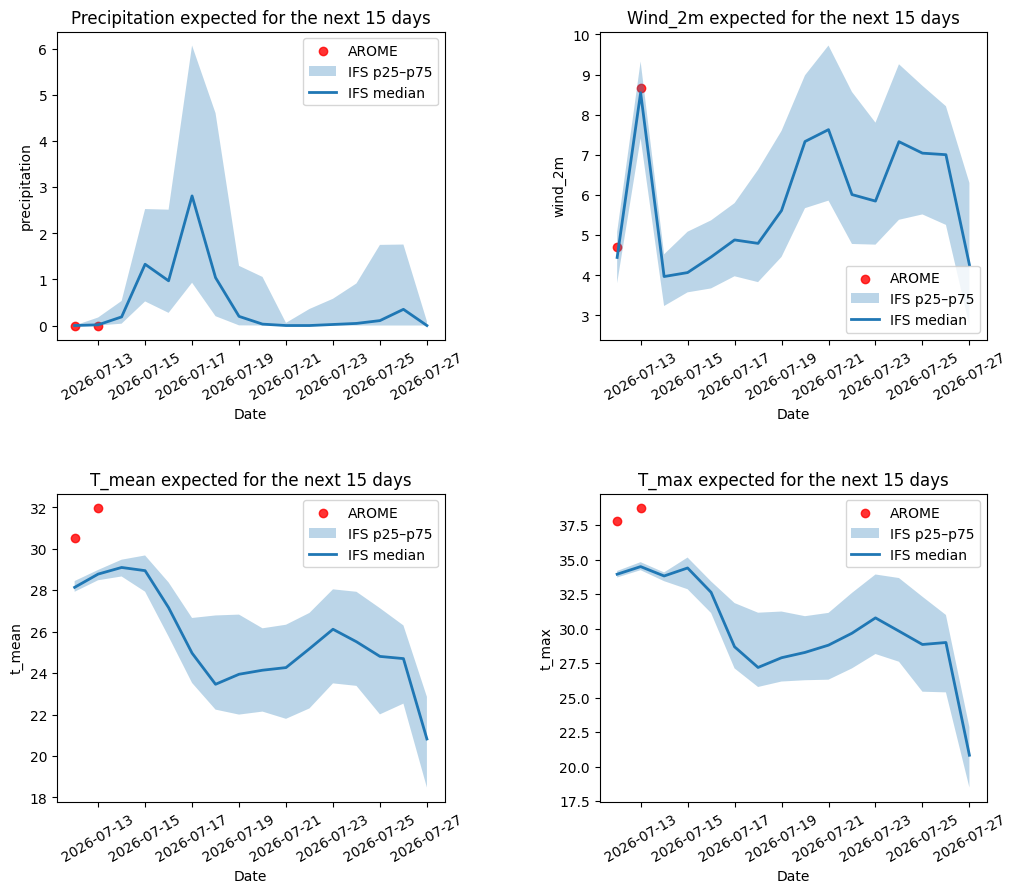

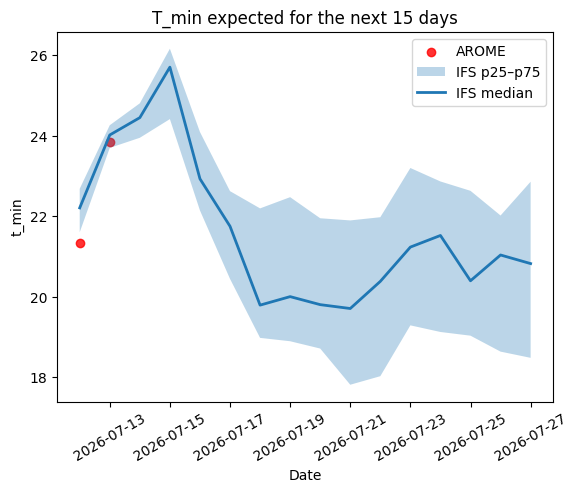

In [5]:
import matplotlib.pyplot as plt

def plot_covariate(arome_df, ifs_df, ax, covariate : str):
    # Make sure dates are sorted and datetime-like
    ifs_df["date"] = pd.to_datetime(ifs_df["date"])
    arome_df["date"] = pd.to_datetime(arome_df["date"])

    # Compute p25, median, p75 across IFS members for each date
    ifs_stats = (
        ifs_df.groupby("date")[covariate]
        .quantile([0.25, 0.5, 0.75])
        .unstack()
        .rename(columns={0.25: "p25", 0.5: "median", 0.75: "p75"})
        .reset_index()
        .sort_values("date")
    )

    

    # AROME scatter
    ax.scatter(arome_df["date"], arome_df[covariate], label="AROME", alpha=0.8, color="red")

    # IFS interquartile range
    ax.fill_between(
        ifs_stats["date"], ifs_stats["p25"], ifs_stats["p75"], alpha=0.3, label="IFS p25–p75"
    )

    # IFS median
    ax.plot(ifs_stats["date"], ifs_stats["median"], label="IFS median", linewidth=2)

    ax.set_xlabel("Date")
    ax.set_ylabel(covariate)
    ax.tick_params("x", rotation=30)
    ax.legend()
    ax.set_title(f"{covariate.capitalize()} expected for the next 15 days")

    return ax


# Plot Precip
fig,axes = plt.subplots(nrows=2,ncols=2, figsize=(12,10))
fig.subplots_adjust(
    wspace=0.4,  # horizontal space between columns
    hspace=0.5,  # vertical space between rows
)
plot_covariate(arome_df=arome_df, ifs_df=ifs_df, ax=axes[0,0], covariate="precipitation")

# Plot Wind
plot_covariate(arome_df=arome_df, ifs_df=ifs_df, ax=axes[0,1], covariate="wind_2m")


# Plot Temperature
plot_covariate(arome_df=arome_df, ifs_df=ifs_df, ax=axes[1,0], covariate="t_mean")

plot_covariate(arome_df=arome_df, ifs_df=ifs_df, ax=axes[1,1], covariate="t_max")


fig,ax = plt.subplots()
plot_covariate(arome_df=arome_df, ifs_df=ifs_df, ax=ax, covariate="t_min")
